In [1]:
# Standard library
from pathlib import Path
import os

# Core scientific Python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    mean_absolute_error,
    root_mean_squared_error,
    r2_score,
    mean_pinball_loss,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Optional packages used later in the notebook
import kagglehub
import optuna
import optuna.visualization as vis
import shap
from xgboost import XGBClassifier, XGBRegressor


In [2]:
# Run this cell only if some packages are missing in your environment.
# In Google Colab or a fresh local environment, it is usually safe to run it once.

%pip install -q kagglehub[pandas-datasets] optuna xgboost shap

Note: you may need to restart the kernel to use updated packages.


## Air Quality dataset

This dataset contains hourly measurements collected by a gas sensor device in an Italian city from March 2004 to February 2005.

It includes both **sensor responses** and **reference pollutant concentrations** measured by a certified analyzer. This makes it useful for both **classification** and **regression** examples.

### Columns

**Date and time**
- `Date`
- `Time`

**Sensor responses**
- `PT08.S1(CO)`
- `PT08.S2(NMHC)`
- `PT08.S3(NOx)`
- `PT08.S4(NO2)`
- `PT08.S5(O3)`

**Reference pollutant concentrations**
- `CO(GT)`
- `NMHC(GT)`
- `C6H6(GT)`
- `NOx(GT)`
- `NO2(GT)`

**Environmental variables**
- `T`
- `RH`
- `AH`


In this notebook, we first turn it into a **multi-class classification** problem and later revisit it as a **regression** task.


In [17]:
# Download dataset
path = Path(kagglehub.dataset_download("fedesoriano/air-quality-data-set"))

# Inspect files
files = os.listdir(path)
print("Downloaded files:", files)

100%|██████████| 248k/248k [00:00<00:00, 1.05MB/s]

Extracting files...
Downloaded files: ['AirQuality.csv']


In [49]:
df = pd.read_csv(path / 'AirQuality.csv',
                 sep=';',
                 decimal=',',
                 na_values=['', ' ', 'NA', -200])

df = df.dropna(axis=1, how='all') #remove completely empty columns

print("Shape:", df.shape)
df.head()

Shape: (9471, 15)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


# Classification problem

## 1) Turning pollutant measurements into classes

The original target variables in this dataset are continuous pollutant concentrations:

- `CO(GT)`
- `NMHC(GT)`
- `C6H6(GT)`
- `NOx(GT)`
- `NO2(GT)`

So, in its raw form, the dataset is naturally a **regression** dataset.  
For the first part of this tutorial, however, we want a **classification** problem.

Rather than defining the target from a single pollutant, we build an overall air-quality label using several pollutant measurements together.

### Step 1: Create pollutant-level categories

For each pollutant, we convert the continuous concentration into three categories:

- `good`
- `medium`
- `bad`

A simple way to do this is to use **quantile-based binning**. This gives classes of roughly similar size and makes the classification task balanced enough for teaching purposes.

### Step 2: Combine them into one final air-quality class

After assigning a class to each pollutant, we combine them into a single target variable called `air_quality_class`.

In this notebook, we use a **worst-pollutant rule**:
- if at least one pollutant is in the `bad` class, the final label becomes `bad`
- otherwise, if at least one pollutant is `medium`, the final label becomes `medium`
- otherwise, the final label is `good`

This is a simple rule, but it is easy to explain and produces an interpretable multiclass target.


In [62]:
df = df.replace(-200, np.nan)

pollutant_cols = ["CO(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)"]

# Keep rows where at least some target information exists
df = df.dropna(subset=pollutant_cols).copy()

# Create per-pollutant classes using quantiles
label_map = {"good": 0, "medium": 1, "bad": 2}

for col in pollutant_cols:
    df[col + "_class"] = pd.qcut(
        df[col],
        q=3,
        labels=["good", "medium", "bad"],
        duplicates="drop"
    )

# Convert to numeric badness scores
class_score_cols = []
for col in pollutant_cols:
    score_col = col + "_score"
    df[score_col] = df[col + "_class"].map(label_map).astype(float)
    class_score_cols.append(score_col)

# Option A: worst-pollutant rule
df["air_quality_score"] = df[class_score_cols].max(axis=1)

# Final label
inverse_map = {0: "good", 1: "medium", 2: "bad"}
df["air_quality_class"] = df["air_quality_score"].map(inverse_map)

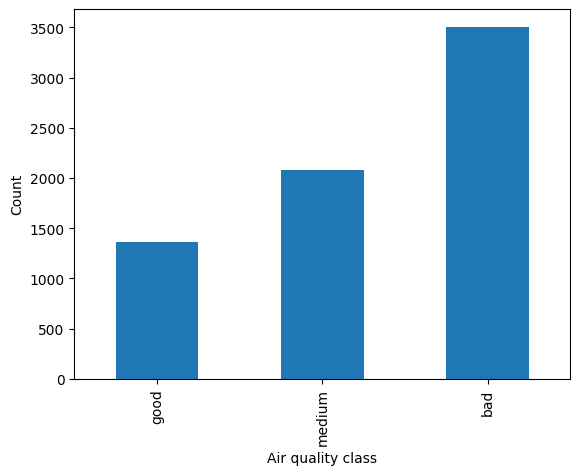

In [63]:
class_order = ["good", "medium", "bad"]

df["air_quality_class"] = pd.Categorical(
    df["air_quality_class"],
    categories=class_order,
    ordered=True
)

df["air_quality_class"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Air quality class")
plt.ylabel("Count")
plt.show()

In [64]:
df["datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H.%M.%S"
)

df = df.sort_values("datetime").reset_index(drop=True)

display(df[["Date", "Time", "datetime"]].head())

,Date,Time,datetime
0,10/03/2004,18.00.00,2004-03-10 18:00:00
1,10/03/2004,19.00.00,2004-03-10 19:00:00
2,10/03/2004,20.00.00,2004-03-10 20:00:00
3,10/03/2004,21.00.00,2004-03-10 21:00:00
4,10/03/2004,22.00.00,2004-03-10 22:00:00


## 2) Train / Validation / Test Split

Before doing any preprocessing or modelling, we must split the data.

Why?

Because if we:
- scale using the full dataset,
- engineer features using the full dataset,
- tune hyperparameters using the full dataset,

we create **data leakage**.

Leakage makes the model look better than it really is, because information from outside the training set indirectly influences the model.

### Strategy

We will:
- define the input features `X`,
- define the target `y`,
- use a **stratified split** because this is a multiclass classification problem,
- create:
    - Train (60%)
    - Validation (20%)
    - Test (20%)


In [82]:
label_col = "air_quality_class"

# Target as strings
y_str = df[label_col]

# Encode labels to integers
le = LabelEncoder()
y = le.fit_transform(y_str)

# Save mapping for later interpretation
class_names = list(le.classes_)
class_mapping = dict(zip(class_names, range(len(class_names))))

# Feature columns only
feature_cols = [
    "PT08.S1(CO)",
    "PT08.S2(NMHC)",
    "PT08.S3(NOx)",
    "PT08.S4(NO2)",
    "PT08.S5(O3)",
    "T",
    "RH",
    "AH",
]

X = df[feature_cols]

print("X shape:", X.shape)
display(y_str.value_counts(dropna=False))
print("Class names:", class_names)
print("Class mapping:", class_mapping)

X shape: (6941, 8)


air_quality_class
bad       3506
medium    2074
good      1361
Name: count, dtype: int64

Class names: ['bad', 'good', 'medium']
Class mapping: {'bad': 0, 'good': 1, 'medium': 2}


We split the dataset in two steps.

First, we separate out the **test set**. This set will remain untouched until the very end of the tutorial, so that it can provide an unbiased estimate of the final model performance.

Then, we split the remaining data into a **training set** and a **validation set**. The training set is used to fit the model, while the validation set is used to compare models and tune hyperparameters.

We use **stratified splitting** in both steps so that the class proportions remain approximately the same in the training, validation, and test sets.

This gives the following final proportions:

- **Training set:** 60%
- **Validation set:** 20%
- **Test set:** 20%

In [83]:
# First split: train+val vs test
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Second split: train vs val
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25, 
    stratify=y_temp,
    random_state=42
)

print("Train size:", X_train.shape)
print("Val size:", X_val.shape)
print("Test size:", X_test.shape)

Train size: (4164, 8)
Val size: (1388, 8)
Test size: (1389, 8)


## Why do we need a validation set?

A simple **train/test split** is enough only if we train a model once and evaluate it once.

In practice, this is almost never what we do. We usually:

- tune hyperparameters
- compare several models
- change preprocessing choices
- engineer new features

As soon as we use the test results to make any of these decisions, the test set is no longer acting as a truly unseen dataset.

That creates a problem: the model design has indirectly adapted to the test set, so the final test score becomes too optimistic.

### Roles of each split

- **Train** → fit the model parameters  
- **Validation** → compare models, tune hyperparameters, and make modelling decisions  
- **Test** → final unbiased evaluation  

In this tutorial, the validation set may also be used later as a **calibration set** for conformal prediction.

### Main idea

The test set should represent unseen future data.

If it influences model development in any way, then it stops being a fair test. That is why we keep it untouched until the final evaluation.

### What if we have limited data?

Instead of using a fixed validation set, we can use **k-fold cross-validation**.

How it works:

1. Split the training data into k folds.
2. Train on (k−1) folds.
3. Validate on the remaining fold.
4. Repeat k times.
5. Average the validation performance.

This allows every sample to be used for both training and validation.

Cross-validation replaces the **validation set**, but **not the test set**.

! We still keep a final test set untouched for one final evaluation.

## 3) Data preprocessing and feature scaling

Before training any model, we must prepare the data.

For this classification task, we keep the preprocessing deliberately simple:
1. select the feature columns,
2. fit the scaler on the training set only,
3. apply the same transformation to validation and test.

Important principle:

All preprocessing steps must be fitted **only on the training set**.  
Validation and test sets must be transformed using parameters learned from training.


### Why do we need feature scaling?

Our input features do not all live on the same numerical scale.

For example:
- sensor response variables can have relatively large values,
- environmental variables such as temperature, relative humidity, and absolute humidity are measured on different ranges.

If features have very different scales, some models may give too much importance to variables with larger numerical values, even if those values are not actually more informative.

### When scaling is necessary

Scaling is especially important for models that depend on:
- distances, such as **K-Nearest Neighbours**,
- dot products or margins, such as **Support Vector Machines**,
- gradient-based optimisation, such as **MLP**.

Tree-based models are usually much less sensitive to scaling, but using one consistent preprocessed dataset keeps the workflow simpler in a teaching notebook.


In [96]:
scaler = StandardScaler()

X_train_prep = scaler.fit_transform(X_train)   # fit only on train
X_val_prep = scaler.transform(X_val)
X_test_prep = scaler.transform(X_test)


### With the data prepared, we can train our first classifier.

In [97]:
knn_clf = KNeighborsClassifier(n_neighbors=10)
knn_clf.fit(X_train_prep, y_train)
y_pred = knn_clf.predict(X_test_prep)
y_pred

array([1, 0, 0, ..., 0, 0, 0], shape=(1389,))

The model now assigns a predicted class to each object in the test set.

However, predictions alone do not tell us whether the classifier is performing well.
To evaluate the quality of the model, we need appropriate classification metrics.

## 4) Classification metrics

For multi-class classification, we use several complementary metrics:

- Confusion matrix
- Accuracy
- Precision (macro)
- Recall (macro)
- F1-score (macro)
- ROC-AUC (one-vs-rest)

Each metric captures a different aspect of model performance, so it is better to interpret them together rather than rely on a single number.

### Confusion matrix

The confusion matrix compares the true labels with the predicted labels.

In a multi-class problem, the diagonal elements correspond to correctly classified objects, while the off-diagonal elements indicate misclassifications. This makes the confusion matrix especially useful for identifying which classes are most often confused with one another.

### Accuracy

Accuracy is the fraction of correctly classified objects among all objects:

$$
\mathrm{Accuracy} = \frac{\text{number of correct predictions}}{\text{total number of predictions}}
$$

Accuracy is easy to interpret, but it can be misleading for imbalanced datasets. A model may obtain high accuracy simply by performing well on the majority class, while still performing poorly on minority classes.

### Precision (macro)

Precision measures how reliable the positive predictions are. For a given class:

$$
\mathrm{Precision} = \frac{TP}{TP + FP}
$$

where:

- $TP$ = true positives
- $FP$ = false positives

High precision means that when the model predicts a class, that prediction is usually correct.

For multi-class classification, **macro-precision** is computed by calculating precision separately for each class and then averaging across all classes:

$$
\mathrm{Precision}_{\mathrm{macro}} = \frac{1}{K}\sum_{i=1}^{K}\mathrm{Precision}_i
$$

where $K$ is the number of classes.

### Recall (macro)

Recall measures how many objects of a given class are correctly identified:

$$
\mathrm{Recall} = \frac{TP}{TP + FN}
$$

where $FN$ = false negatives.

High recall means that the model misses only a small fraction of objects belonging to that class.

For multi-class classification, **macro-recall** is:

$$
\mathrm{Recall}_{\mathrm{macro}} = \frac{1}{K}\sum_{i=1}^{K}\mathrm{Recall}_i
$$

This metric is particularly important when minority classes are of interest.

<figure style="text-align: center;">
  <img src="images/Precisionrecall.svg" width="300">
  <figcaption>
    </em> Precision and recall diagram showing true positives, false positives, and false negatives.
    Image by <a href="//commons.wikimedia.org/wiki/User:Walber" title="User:Walber">Walber</a>,
    own work,
    licensed under
    <a href="https://creativecommons.org/licenses/by-sa/4.0" title="Creative Commons Attribution-Share Alike 4.0">CC BY-SA 4.0</a>.
    <a href="https://commons.wikimedia.org/w/index.php?curid=36926283">Source</a>.
  </figcaption>
</figure>

### F1-score (macro)

The F1-score combines precision and recall through their harmonic mean:

$$
F1 = 2 \cdot \frac{\mathrm{Precision} \cdot \mathrm{Recall}}{\mathrm{Precision} + \mathrm{Recall}}
$$

A high F1-score indicates a good balance between avoiding false positives and false negatives.

For multi-class classification, **macro-F1** is obtained by averaging the F1-score over all classes:

$$
F1_{\mathrm{macro}} = \frac{1}{K}\sum_{i=1}^{K}F1_i
$$

This is often more informative than accuracy when working with imbalanced datasets.

### ROC-AUC (one-vs-rest)

<figure style="text-align: center;">
  <img src="images/Roc_curve.svg" width="300">
  <figcaption>
    </em> Example ROC curves illustrating different levels of classifier performance.
    Image by
    <a href="https://commons.wikimedia.org/wiki/User:Cmglee">cmglee</a>
    and
    <a href="https://commons.wikimedia.org/wiki/User:MartinThoma">MartinThoma</a>,
    licensed under
    <a href="https://creativecommons.org/licenses/by-sa/4.0">CC BY-SA 4.0</a>.
    <a href="https://commons.wikimedia.org/w/index.php?curid=109730045">Source</a>.
  </figcaption>
</figure>

The ROC (Receiver Operating Characteristic) curve shows the trade-off between the true positive rate and the false positive rate at different decision thresholds.

The **area under the ROC curve (AUC)** summarizes this curve with a single number. It measures how well the classifier separates the positive and negative classes across all possible thresholds. An AUC value close to 1 indicates strong class separability, while an AUC value close to 0.5 corresponds to near-random performance.

For multi-class classification, ROC-AUC is commonly computed using the **one-vs-rest** approach. In this setting, each class is treated in turn as the positive class, while all remaining classes are grouped together as the negative class. An ROC curve and the corresponding AUC are then computed for each class.

### Why macro-averaging?

Macro-averaging gives equal weight to each class, regardless of how many examples belong to that class.

This is important because our dataset is imbalanced. If we used only overall metrics, the performance on majority classes could dominate the result and hide poor performance on minority classes. Macro-averaged metrics therefore provide a more balanced evaluation across the full set of classes.

In [99]:
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score
)

In [100]:
# numeric labels 0..3 in the encoder order
labels_sorted = list(range(len(le.classes_)))
class_names = list(le.classes_)  # axis labels in same order as labels_sorted

def evaluate_model(name, model, X_val, y_val, normalize_cm=False):
    """
    y_val must be encoded ints (0..K-1).
    Confusion matrix will display class names (strings).
    """
    y_pred = model.predict(X_val)

    y_proba = None
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_val)

    acc  = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average="macro", labels=labels_sorted, zero_division=0)
    rec = recall_score(y_val, y_pred, average="macro", labels=labels_sorted, zero_division=0)
    f1 = f1_score(y_val, y_pred, average="macro", labels=labels_sorted, zero_division=0)

    print(f"\n{name}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"Macro-F1:  {f1:.4f}")

    if y_proba is not None:
        auc = roc_auc_score(y_val, y_proba, multi_class="ovr")
        print(f"ROC-AUC (OvR): {auc:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_val, y_pred, labels=labels_sorted)

    if normalize_cm:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f" if normalize_cm else "d",
        cmap="Blues",
        cbar=True,
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion matrix{' (normalized)' if normalize_cm else ''}")
    plt.tight_layout()
    plt.show()


KNN
Accuracy:  0.8559
Precision: 0.8412
Recall:    0.8339
Macro-F1:  0.8373
ROC-AUC (OvR): 0.9601


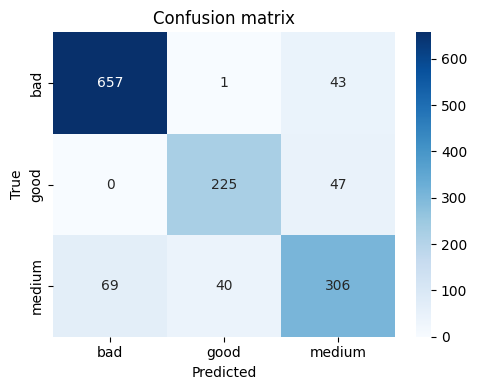

In [101]:
knn_clf = KNeighborsClassifier(n_neighbors=10)
knn_clf.fit(X_train_prep, y_train)

evaluate_model("KNN", knn_clf, X_val_prep, y_val)

**Exercise:** Try changing the number of neighbors. What do you notice?


KNN
Accuracy:  0.6722
Precision: 0.4305
Recall:    0.5341
Macro-F1:  0.4753
ROC-AUC (OvR): 0.8869


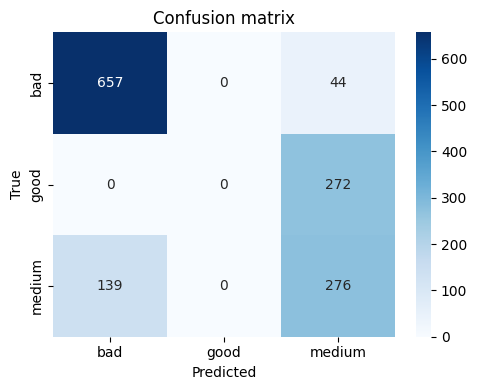

In [104]:
knn_high_number = KNeighborsClassifier(n_neighbors=2000)
knn_high_number.fit(X_train_prep, y_train)

evaluate_model("KNN", knn_high_number, X_val_prep, y_val)

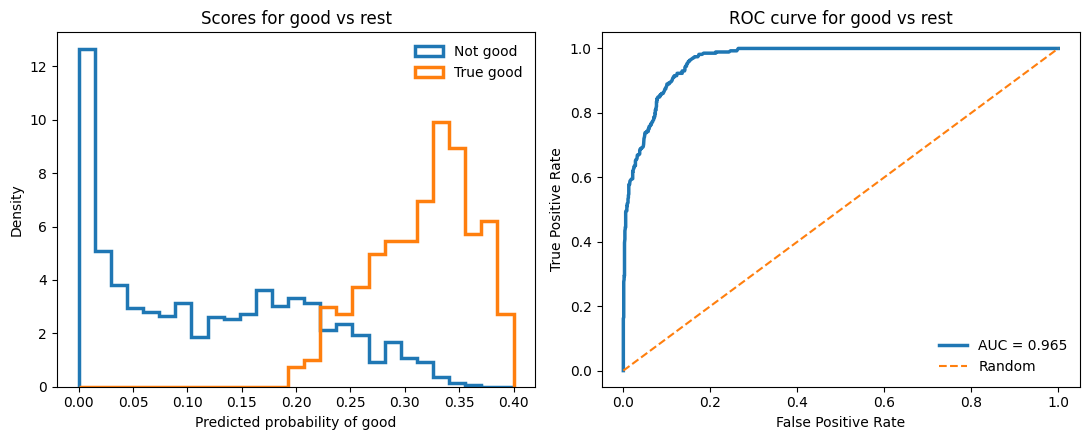

In [109]:
# Choose class
target_name = "good"
target_id = le.transform([target_name])[0]

# Predicted probabilities
y_proba = knn_high_number.predict_proba(X_val_prep)

# Binary truth for one-vs-rest
y_true_bin = (y_val == target_id).astype(int)

# Scores for the chosen class
y_score = y_proba[:, target_id]

# ROC data
fpr, tpr, _ = roc_curve(y_true_bin, y_score)
auc_val = roc_auc_score(y_true_bin, y_score)

# Split scores for left panel
target_scores_true = y_score[y_true_bin == 1]
target_scores_rest = y_score[y_true_bin == 0]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Left: score distributions
bins = np.linspace(y_score.min(), y_score.max(), 28)

axes[0].hist(
    target_scores_rest,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=2.5,
    label=f"Not {target_name}"
)

axes[0].hist(
    target_scores_true,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=2.5,
    label=f"True {target_name}"
)

axes[0].set_title(f"Scores for {target_name} vs rest")
axes[0].set_xlabel(f"Predicted probability of {target_name}")
axes[0].set_ylabel("Density")
axes[0].legend(frameon=False)

# Right: ROC curve
axes[1].plot(fpr, tpr, linewidth=2.5, label=f"AUC = {auc_val:.3f}")
axes[1].plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, label="Random")
axes[1].set_title(f"ROC curve for {target_name} vs rest")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

Although the one-vs-rest ROC curve for `good` class looks relatively strong, the confusion matrix may still show that the classifier does not predict `good` very often as the final class. This is because one-vs-rest evaluation measures how well the model ranks true `good` examples above non-`good` examples using the score `P(good)`, whereas the confusion matrix reflects the final multiclass decision based on the largest predicted probability. A class can therefore have good one-vs-rest ranking performance while still not being selected as the top predicted class if another class, such as `medium` or `bad`, receives a slightly higher probability more often.

This example shows that different evaluation metrics capture different aspects of model performance. One-vs-rest ROC-AUC measures how well the model ranks a given class against the rest, while the confusion matrix and macro-averaged metrics evaluate the final multiclass predictions. A classifier may therefore show good ranking performance for the class while still performing poorly as a whole.

## 5) Training the models

So far, we have used KNN as a simple model to introduce the classification workflow and evaluation metrics. We now move on to training and comparing other classification models.

### Decision tree concept

A decision tree makes predictions by applying a sequence of simple rules based on the input features. At each step, the model splits the data into smaller groups in order to separate the classes as well as possible.


**Exercise: Building a simple decision tree from scratch**

Before using scikit-learn's implementation, let us build a very simple decision tree classifier ourselves.

A decision tree works by repeatedly splitting the data into smaller groups that are as pure as possible (meaning that in the end the split should consist ideally of only one class). In classification, one common measure of impurity is the **Gini impurity**:

$$
G = 1 - \sum_{k=1}^{K} p_k^2
$$

where $p_k$ is the fraction of samples in class $k$.

At each node, the tree:
1. tries candidate splits
2. evaluates how pure the left and right subsets become
3. chooses the split with the lowest weighted impurity
4. repeats the procedure recursively

We will implement the classifier step by step.

In [ ]:
class MyDecisionTreeClassifier:
    def __init__(self, max_depth=3, min_samples_split=5):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree_ = None

    def _gini(self, y):
        """
        TODO 1: Compute the Gini impurity.
        """
        _, counts = np.unique(y, return_counts=True)
        p = ______________________________
        return ______________________________

    def _majority_class(self, y):
        """
        A leaf predicts the most common class among the samples that reached it.
        """
        values, counts = np.unique(y, return_counts=True)
        return values[np.argmax(counts)]

    def _split_dataset(self, X, y, feature_idx, threshold):
        """
        TODO 2: Split the dataset into left and right child nodes.
        """
        left_mask = ______________________________
        right_mask = ______________________________
        return X[left_mask], X[right_mask], y[left_mask], y[right_mask]

    def _weighted_gini_split(self, X, y, feature_idx, threshold):
        """
        TODO 3: Compute the weighted impurity after a split.
        """
        _, _, y_left, y_right = self._split_dataset(X, y, feature_idx, threshold)

        if len(y_left) == 0 or len(y_right) == 0:
            return ______________________________

        n = len(y)
        return (
            ______________________________
            + ______________________________
        )

    def _find_best_split(self, X, y):
        best_feature = None
        best_threshold = None
        best_score = np.inf

        n_features = X.shape[1]

        for j in range(n_features):
            thresholds = np.unique(X[:, j])

            for t in thresholds:
                score = self._weighted_gini_split(X, y, j, t)

                if score < best_score:
                    best_score = score
                    best_feature = j
                    best_threshold = t

        return best_feature, best_threshold, best_score

    def _build_tree(self, X, y, depth):
        if len(np.unique(y)) == 1:
            return {"type": "leaf", "class": y[0]}

        """ 
        TODO 4: Stop splitting if the maximum depth is reached.
        """
        if depth >= ______________________________:
            return {"type": "leaf", "class": self._majority_class(y)}

        if len(y) < self.min_samples_split:
            return {"type": "leaf", "class": self._majority_class(y)}

        feature_idx, threshold, score = self._find_best_split(X, y)
        parent_gini = self._gini(y)

        if feature_idx is None or np.isinf(score):
            return {"type": "leaf", "class": self._majority_class(y)}

        """
        TODO 5: Compute the impurity improvement.
        """
        improvement = ______________________________
        if improvement <= 1e-6:
            return {"type": "leaf", "class": self._majority_class(y)}

        X_left, X_right, y_left, y_right = self._split_dataset(X, y, feature_idx, threshold)

        if len(y_left) == 0 or len(y_right) == 0:
            return {"type": "leaf", "class": self._majority_class(y)}

        return {
            "type": "node",
            "feature_idx": feature_idx,
            "threshold": threshold,
            "left": self._build_tree(X_left, y_left, depth + 1),
            "right": self._build_tree(X_right, y_right, depth + 1),
        }

    def _predict_one(self, x, node):
        if node["type"] == "leaf":
            return node["class"]

        """
        TODO 6: Follow the correct branch recursively.
        """
        if x[node["feature_idx"]] <= node["threshold"]:
            return ______________________________
        else:
            return ______________________________

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        self.tree_ = self._build_tree(X, y, depth=0)
        return self

    def predict(self, X):
        X = np.asarray(X)

        if self.tree_ is None:
            raise ValueError("The tree is not fitted yet. Call fit(X, y) first.")

        return np.array([self._predict_one(x, self.tree_) for x in X])

In [275]:
#### Instructor solution

class MyDecisionTreeClassifier:
    def __init__(self, max_depth=3, min_samples_split=5):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree_ = None

    def _gini(self, y):
        _, counts = np.unique(y, return_counts=True)
        p = counts / counts.sum()
        return 1.0 - np.sum(p ** 2)

    def _majority_class(self, y):
        values, counts = np.unique(y, return_counts=True)
        return values[np.argmax(counts)]

    def _split_dataset(self, X, y, feature_idx, threshold):
        left_mask = X[:, feature_idx] <= threshold
        right_mask = ~left_mask
        return X[left_mask], X[right_mask], y[left_mask], y[right_mask]

    def _weighted_gini_split(self, X, y, feature_idx, threshold):
        _, _, y_left, y_right = self._split_dataset(X, y, feature_idx, threshold)

        if len(y_left) == 0 or len(y_right) == 0:
            return np.inf

        n = len(y)
        return (
            len(y_left) / n * self._gini(y_left)
            + len(y_right) / n * self._gini(y_right)
        )

    def _find_best_split(self, X, y):
        best_feature = None
        best_threshold = None
        best_score = np.inf

        n_features = X.shape[1]

        for j in range(n_features):
            thresholds = np.unique(X[:, j])

            for t in thresholds:
                score = self._weighted_gini_split(X, y, j, t)

                if score < best_score:
                    best_score = score
                    best_feature = j
                    best_threshold = t

        return best_feature, best_threshold, best_score

    def _build_tree(self, X, y, depth):
        # stopping rules
        if len(np.unique(y)) == 1:
            return {"type": "leaf", "class": y[0]}

        if depth >= self.max_depth:
            return {"type": "leaf", "class": self._majority_class(y)}

        if len(y) < self.min_samples_split:
            return {"type": "leaf", "class": self._majority_class(y)}

        feature_idx, threshold, score = self._find_best_split(X, y)
        
        parent_gini = self._gini(y)

        if feature_idx is None or np.isinf(score):
            return {"type": "leaf", "class": self._majority_class(y)}

        improvement = parent_gini - score
        if improvement <= 1e-6:
            return {"type": "leaf", "class": self._majority_class(y)}

        if feature_idx is None or np.isinf(score):
            return {"type": "leaf", "class": self._majority_class(y)}

        X_left, X_right, y_left, y_right = self._split_dataset(X, y, feature_idx, threshold)

        if len(y_left) == 0 or len(y_right) == 0:
            return {"type": "leaf", "class": self._majority_class(y)}

        return {
            "type": "node",
            "feature_idx": feature_idx,
            "threshold": threshold,
            "left": self._build_tree(X_left, y_left, depth + 1),
            "right": self._build_tree(X_right, y_right, depth + 1),
        }

    def _predict_one(self, x, node):
        if node["type"] == "leaf":
            return node["class"]

        if x[node["feature_idx"]] <= node["threshold"]:
            return self._predict_one(x, node["left"])
        else:
            return self._predict_one(x, node["right"])

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        self.tree_ = self._build_tree(X, y, depth=0)
        return self

    def predict(self, X):
        X = np.asarray(X)

        if self.tree_ is None:
            raise ValueError("The tree is not fitted yet. Call fit(X, y) first.")

        return np.array([self._predict_one(x, self.tree_) for x in X])
    
    def print_tree(self, node=None, depth=0, feature_names=None, class_names=None):
        if node is None:
            node = self.tree_

        indent = "  " * depth

        if node["type"] == "leaf":
            cls = node["class"]
            cls_name = class_names[cls] if class_names is not None else cls
            print(f"{indent}Leaf -> {cls_name}")
            return

        feat = node["feature_idx"]
        feat_name = feature_names[feat] if feature_names is not None else f"x[{feat}]"
        thr = node["threshold"]

        print(f"{indent}if {feat_name} <= {thr:.4f}:")
        self.print_tree(node["left"], depth + 1, feature_names, class_names)

        print(f"{indent}else:  # {feat_name} > {thr:.4f}")
        self.print_tree(node["right"], depth + 1, feature_names, class_names)

In [112]:
my_tree = MyDecisionTreeClassifier(max_depth=3, min_samples_split=10)
my_tree.fit(X_train_prep, y_train)

In [118]:
feature_names = feature_cols.copy()

if PT08.S2(NMHC) <= 0.3946:
  if PT08.S2(NMHC) <= -0.5320:
    if T <= -0.3702:
      Leaf -> medium
    else:  # T > -0.3702
      Leaf -> good
  else:  # PT08.S2(NMHC) > -0.5320
    if PT08.S4(NO2) <= -0.2996:
      Leaf -> bad
    else:  # PT08.S4(NO2) > -0.2996
      Leaf -> medium
else:  # PT08.S2(NMHC) > 0.3946
  Leaf -> bad



Custom tree
Accuracy:  0.8199
Precision: 0.8113
Recall:    0.7960
Macro-F1:  0.7966


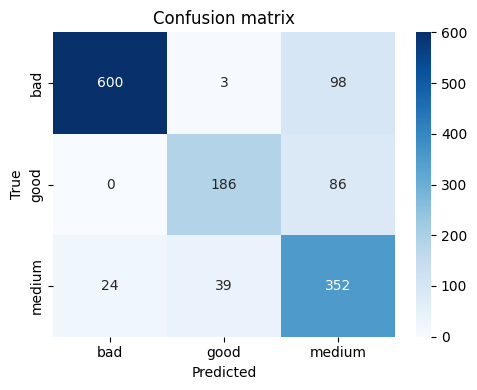

In [119]:
evaluate_model('Custom tree', my_tree, X_val_prep, y_val, normalize_cm=False)

The main lesson is that decision trees are based on a simple recursive idea, yet this idea can already produce a strong classifier. Our custom implementation is much simpler than a production library model, but it still performs well, showing that the essential logic of decision trees is both interpretable and powerful.

## Library models
After building simple classifiers from scratch, we now return to library implementations. The goal is no longer to reproduce the algorithm manually, but to train, evaluate, and compare practical models on the same task.

### 1. Decision Tree

We now move from our custom implementation to a standard library model.


Decision Tree
Accuracy:  0.7797
Precision: 0.7720
Recall:    0.7391
Macro-F1:  0.7421
ROC-AUC (OvR): 0.9157


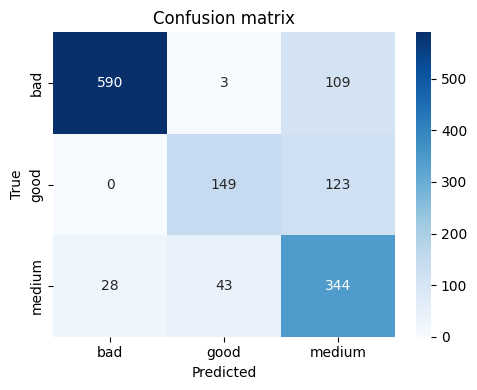

In [152]:
tree_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf.fit(X_train_prep, y_train)

evaluate_model("Decision Tree", tree_clf, X_test_prep, y_test, normalize_cm=False)

#### Model hyperparameters

A decision tree has several hyperparameters that control its complexity.

Some of the most important ones are:

- `max_depth`: the maximum depth of the tree. Smaller values produce simpler trees, while larger values allow the model to fit more complex patterns.
- `min_samples_split`: the minimum number of samples required to split an internal node.
- `min_samples_leaf`: the minimum number of samples required in a leaf node.
- `criterion`: the function used to measure the quality of a split, for example `"gini"` or `"entropy"`.

These hyperparameters are not learned from the data directly. Instead, they must be chosen by the user.

---

For a node containing class fractions $p_1, p_2, \dots, p_K$, the entropy is defined as

$$
H = -\sum_{k=1}^{K} p_k \log_2 p_k
$$

Entropy is equal to 0 when all samples in the node belong to a single class, and it is larger when the classes are more mixed.

---

#### Why tune hyperparameters?

The performance of a decision tree depends strongly on its hyperparameters.

For example:
- if `max_depth` is too small, the tree may underfit;
- if `max_depth` is too large, the tree may overfit;
- if `min_samples_leaf` is too small, the model may create unstable leaves;
- if `min_samples_split` is too large, the model may stop growing too early.

Rather than selecting these values manually, we can search for a better combination automatically.

Before moving on, let us recall the role of the train/validation/test split.

The **training set** is used to fit the model. In this tutorial, the **validation set** is reserved for **conformal calibration**, while the **test set** is kept aside for the final evaluation only.

This distinction becomes especially important once we start tuning hyperparameters. Since the validation set will later be used for conformal prediction, we should not use it also to optimize the model. Instead, hyperparameter tuning is performed within the training set, for example by cross-validation. After selecting the best hyperparameters, we retrain the model on the full training set, use the validation set for calibration, and evaluate the final performance on the test set.

In [140]:
def objective_tree(trial):
    clf = DecisionTreeClassifier(
        max_depth=trial.suggest_int("max_depth", 2, 20),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 10),
        criterion=trial.suggest_categorical("criterion", ["gini", "entropy"]),
        random_state=42,
    )

    clf.fit(X_train_prep, y_train)
    y_val_pred = clf.predict(X_val_prep)

    return f1_score(y_val, y_val_pred, average="macro")

In [141]:
study_tree = optuna.create_study(direction="maximize")
study_tree.optimize(objective_tree, n_trials=50)

[I 2026-03-26 23:56:27,710] A new study created in memory with name: no-name-239c187e-9e7e-4fff-9285-efde7d49b062
[I 2026-03-26 23:56:27,731] Trial 0 finished with value: 0.8835277872221128 and parameters: {'max_depth': 7, 'min_samples_split': 10, 'min_samples_leaf': 4, 'criterion': 'entropy'}. Best is trial 0 with value: 0.8835277872221128.
[I 2026-03-26 23:56:27,741] Trial 1 finished with value: 0.7966445912611021 and parameters: {'max_depth': 3, 'min_samples_split': 15, 'min_samples_leaf': 5, 'criterion': 'gini'}. Best is trial 0 with value: 0.8835277872221128.
[I 2026-03-26 23:56:27,752] Trial 2 finished with value: 0.8761588917565181 and parameters: {'max_depth': 7, 'min_samples_split': 18, 'min_samples_leaf': 3, 'criterion': 'gini'}. Best is trial 0 with value: 0.8835277872221128.
[I 2026-03-26 23:56:27,767] Trial 3 finished with value: 0.8673693342282297 and parameters: {'max_depth': 6, 'min_samples_split': 13, 'min_samples_leaf': 4, 'criterion': 'gini'}. Best is trial 0 with va

In [142]:
study_tree.best_params

{'max_depth': 7,
 'min_samples_split': 16,
 'min_samples_leaf': 5,
 'criterion': 'entropy'}

In [144]:
vis.plot_optimization_history(study_tree)

In [145]:
vis.plot_param_importances(study_tree)


Best tree
Accuracy:  0.8776
Precision: 0.8625
Recall:    0.8740
Macro-F1:  0.8677
ROC-AUC (OvR): 0.9622


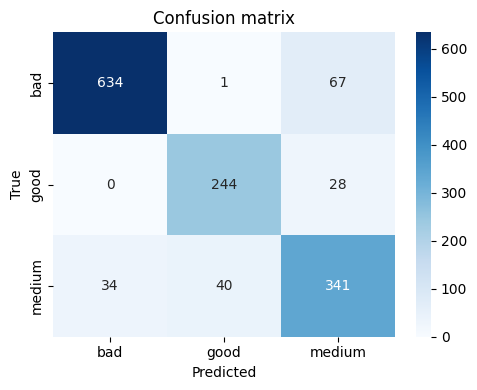

In [153]:
best_tree = DecisionTreeClassifier(
    **study_tree.best_params,
    random_state=42,
)

best_tree.fit(X_train_prep, y_train)

evaluate_model('Best tree', best_tree, X_test_prep, y_test)

### 2. Random Forest

A single decision tree is easy to understand and interpret, but it can also be quite unstable: small changes in the training data may lead to a very different tree. In addition, a single tree can easily overfit the data and capture noise instead of general patterns.

A **Random Forest** addresses this problem by combining the predictions of **many decision trees** instead of relying on just one. Each tree is trained on a slightly different version of the training set, created through **bootstrap sampling** (random sampling with replacement). In addition, at each split, the algorithm considers only a **random subset of features** rather than all available features.

These two sources of randomness make the trees less similar to each other. While individual trees may still make mistakes, their errors are often different, and combining their predictions leads to a more robust model. In classification tasks, the final prediction is usually obtained by **majority vote** across all trees.

In practice, Random Forests often provide better and more stable performance than a single decision tree, while still working very well on structured tabular data.


Random Forest
Accuracy:  0.8978
Precision: 0.8871
Recall:    0.8961
Macro-F1:  0.8913
ROC-AUC (OvR): 0.9796


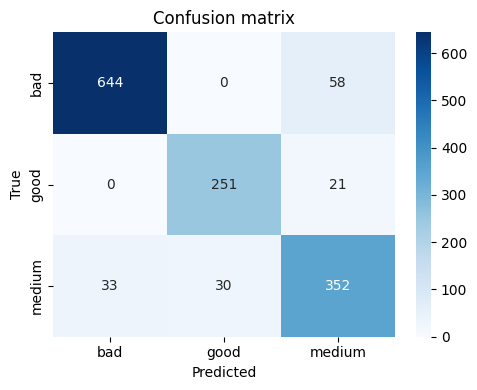

In [151]:
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_train_prep, y_train)

evaluate_model("Random Forest", rf_clf, X_test_prep, y_test, normalize_cm=False)

#### Model hyperparameters

A Random Forest has several hyperparameters that control the size of the ensemble and the complexity of the individual trees.

Some of the most important ones are:

- `n_estimators`: the number of decision trees in the forest. More trees usually improve stability, but also increase computation time.
- `max_depth`: the maximum depth of each tree. Smaller values make the trees simpler, while larger values allow the model to learn more complex patterns.
- `min_samples_split`: the minimum number of samples required to split an internal node.
- `min_samples_leaf`: the minimum number of samples required in a leaf node.
- `max_features`: the number of features considered at each split. Using only a subset of features helps make the trees less correlated.
- `bootstrap`: whether bootstrap samples of the training data are used to train the individual trees.
- `criterion`: the function used to measure the quality of a split, for example `"gini"` or `"entropy"`.

#### Exercise: prepare an Optuna study for Random Forest tuning

Now let us optimize the Random Forest hyperparameters with **Optuna**.

Your task is to write an `objective(trial)` function that:

1. suggests a set of Random Forest hyperparameters,
2. creates a `RandomForestClassifier`,
3. evaluates it with `cross_val_score`,
4. returns the chosen mean score for Optuna to maximize.

Use the following hyperparameters as a starting point:

- `n_estimators`
- `max_depth`
- `min_samples_split`
- `min_samples_leaf`
- `max_features`

You can use `trial.suggest_int(...)` and `trial.suggest_categorical(...)` to define the search space.

Use `cross_val_score`, as in the Decision Tree example, with either:
- `scoring="accuracy"`, or
- `scoring="f1_macro"`

In [147]:
def objective_rf(trial):
    # 1. Suggest hyperparameters
    # Example:
    # n_estimators = trial.suggest_int(...)
    # max_depth = trial.suggest_int(...)
    # ...

    # 2. Create the model
    # clf = RandomForestClassifier(
    #     ...,
    #     random_state=42,
    #     n_jobs=-1,
    #   )

    # 3. Fit on train
    # clf.fit()

    # 4. Predict on validation
    # y_pred_val =

    # 5. Return validation score
    # scores =
    return np.mean(scores)

In [148]:
# Instructor solution


def objective_rf(trial):
    # 1. Suggest hyperparameters
    n_estimators = trial.suggest_int("n_estimators", 100, 500)
    max_depth = trial.suggest_int("max_depth", 3, 30)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])

    # 2. Create the model
    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42,
        n_jobs=-1,
    )

    # 3. Fit on train
    clf.fit(X_train_prep, y_train)

    # 4. Predict on validation
    y_val_pred = clf.predict(X_val_prep)

    # 5. Return validation score
    return f1_score(y_val, y_val_pred, average="macro")

In [149]:
study_rf = optuna.create_study(direction="maximize")
study_rf.optimize(objective_rf, n_trials=50)

[I 2026-03-26 23:59:31,860] A new study created in memory with name: no-name-24a3d199-aafe-4ac3-9821-376550f3a973
[I 2026-03-26 23:59:32,422] Trial 0 finished with value: 0.8781173583123142 and parameters: {'n_estimators': 347, 'max_depth': 5, 'min_samples_split': 18, 'min_samples_leaf': 6, 'max_features': 'log2'}. Best is trial 0 with value: 0.8781173583123142.
[I 2026-03-26 23:59:33,269] Trial 1 finished with value: 0.9023022853692962 and parameters: {'n_estimators': 424, 'max_depth': 22, 'min_samples_split': 6, 'min_samples_leaf': 7, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.9023022853692962.
[I 2026-03-26 23:59:33,633] Trial 2 finished with value: 0.8843892855310873 and parameters: {'n_estimators': 181, 'max_depth': 6, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.9023022853692962.
[I 2026-03-26 23:59:33,915] Trial 3 finished with value: 0.9005263080372932 and parameters: {'n_estimators': 105, 'max_depth': 27, 'mi


Best RF
Accuracy:  0.8985
Precision: 0.8862
Recall:    0.9003
Macro-F1:  0.8927
ROC-AUC (OvR): 0.9806


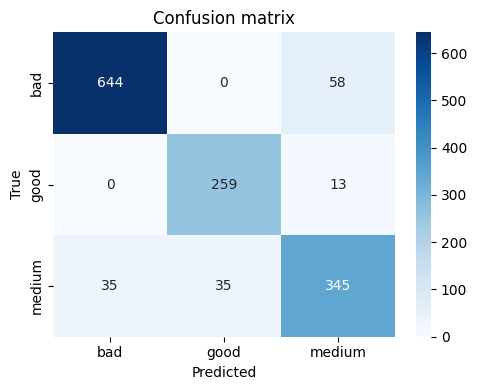

In [154]:
best_rf = RandomForestClassifier(
    **study_rf.best_params,
    random_state=42,
)

best_rf.fit(X_train_prep, y_train)

evaluate_model('Best RF', best_rf, X_test_prep, y_test)

The optimized model improves substantially over the single decision tree. The overall accuracy increases to about 0.94, and the macro-F1 score rises to about 0.93, indicating better balanced performance across classes. The confusion matrix shows that UCD objects are classified almost perfectly, while the largest remaining confusion is still between Variable stars and candidate YSOs. This suggests that the stronger ensemble model captures the data structure better, but some classes remain intrinsically harder to separate.

### 3. XGBoost

So far, we have seen how a single decision tree can learn non-linear patterns, and how a Random Forest can improve stability by combining many trees trained independently.

**XGBoost** (Extreme Gradient Boosting) takes a different approach. Instead of building many independent trees and averaging their predictions, it builds trees **sequentially**. Each new tree is trained to correct the errors made by the previous ones.

This boosting strategy often leads to stronger predictive performance, especially for structured tabular data. In practice, XGBoost is one of the most popular and effective machine-learning methods for classification and regression tasks.

The figure below illustrates the general idea of **boosting**: weak learners are added sequentially, and each new model focuses on correcting the mistakes of the previous ones.

<figure style="text-align: center;">
  <img src="images/Ensemble_Boosting.png" width="500">
  <figcaption>
    Illustration of the boosting idea: weak learners are added sequentially, and each new model focuses on correcting previous errors.
    Image by <a href="//commons.wikimedia.org/wiki/User:Sirakorn" title="User:Sirakorn">Sirakorn</a>,
    own work,
    licensed under
    <a href="https://creativecommons.org/licenses/by-sa/4.0" title="Creative Commons Attribution-Share Alike 4.0">CC BY-SA 4.0</a>.
    <a href="https://commons.wikimedia.org/w/index.php?curid=85888769">Source</a>.
  </figcaption>
</figure>

Compared to a single decision tree, XGBoost is usually more accurate and less prone to overfitting. Compared to Random Forest, it often achieves better performance, but it also introduces more hyperparameters and can be less straightforward to tune.


XGBoost
Accuracy:  0.9028
Precision: 0.8923
Recall:    0.9042
Macro-F1:  0.8978
ROC-AUC (OvR): 0.9810


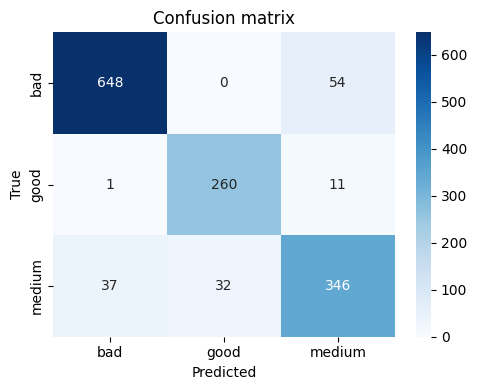

In [155]:
xgb_clf = XGBClassifier(
    random_state=42,
)

xgb_clf.fit(X_train_prep, y_train)

evaluate_model("XGBoost", xgb_clf, X_test_prep, y_test, normalize_cm=False)

#### Model hyperparameters

XGBoost has several hyperparameters that control both the complexity of the individual trees and the boosting process.

Some of the most important ones are:

- `n_estimators`: the number of boosting rounds, that is, how many trees are added to the model.
- `max_depth`: the maximum depth of each tree. Larger values allow the model to learn more complex patterns, but also increase the risk of overfitting.
- `learning_rate`: controls how strongly each new tree contributes to the final model. Smaller values make learning slower, but can improve generalization.
- `subsample`: the fraction of training samples used to train each tree. Using only part of the data can help reduce overfitting.
- `colsample_bytree`: the fraction of features used when building each tree.
- `min_child_weight`: controls how easily the algorithm is allowed to create new leaf nodes.
- `gamma`: the minimum loss reduction required to make an additional split.

In [156]:
def objective_xgb(trial):
    clf = XGBClassifier(
        n_estimators=trial.suggest_int("n_estimators", 50, 400),
        max_depth=trial.suggest_int("max_depth", 2, 10),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        random_state=42,
        eval_metric="mlogloss",
    )

    clf.fit(X_train_prep, y_train)

    y_val_pred = clf.predict(X_val_prep)

    return f1_score(y_val, y_val_pred, average="macro")

In [157]:
study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(objective_xgb, n_trials=50)

[I 2026-03-27 00:01:43,224] A new study created in memory with name: no-name-886cc6ee-40db-4454-8951-359997eb1e3c
[I 2026-03-27 00:01:43,556] Trial 0 finished with value: 0.8985497942698762 and parameters: {'n_estimators': 201, 'max_depth': 3, 'learning_rate': 0.06964701232553408, 'subsample': 0.8352901534180401, 'colsample_bytree': 0.8602052885480919}. Best is trial 0 with value: 0.8985497942698762.
[I 2026-03-27 00:01:44,186] Trial 1 finished with value: 0.901408677878024 and parameters: {'n_estimators': 232, 'max_depth': 5, 'learning_rate': 0.03202680093640716, 'subsample': 0.8623307577954178, 'colsample_bytree': 0.8417745288550119}. Best is trial 1 with value: 0.901408677878024.
[I 2026-03-27 00:01:44,871] Trial 2 finished with value: 0.9004350558313773 and parameters: {'n_estimators': 196, 'max_depth': 6, 'learning_rate': 0.03598141674383716, 'subsample': 0.8864047079205344, 'colsample_bytree': 0.6440653587123597}. Best is trial 1 with value: 0.901408677878024.
[I 2026-03-27 00:01


Best XGBoost
Accuracy:  0.9006
Precision: 0.8880
Recall:    0.9032
Macro-F1:  0.8949
ROC-AUC (OvR): 0.9814


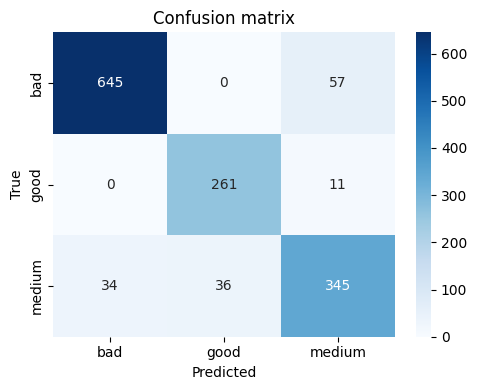

In [181]:
best_xgb = XGBClassifier(
    **study_xgb.best_params,
    random_state=42,
)

best_xgb.fit(X_train_prep, y_train)

evaluate_model('Best XGBoost', best_xgb, X_test_prep, y_test)

### 4. Support Vector Classifier

So far, we have explored tree-based models such as Decision Trees, Random Forests and XGBoost.  
We now turn to a different family of algorithms: **Support Vector Machines**.

A **Support Vector Classifier (SVC)** tries to separate classes by finding a decision boundary with the **largest possible margin**, that is, the widest gap between classes. The training points that matter most for defining this boundary are called **support vectors**.

When the classes are not linearly separable, SVC can use a **kernel** to build a more flexible decision boundary. A common choice is the **RBF kernel**, which allows the model to capture non-linear patterns in the data.

SVC can perform very well on classification tasks when the features are informative and properly preprocessed. However, unlike tree-based models, it does **not** handle missing values directly, and it is sensitive to the numerical scale of the features. For this reason, imputation and feature scaling are especially important before training an SVC.

Another important difference is that SVC is usually less interpretable than tree-based models, and its performance can depend strongly on hyperparameters such as `C` and `gamma`. This makes careful tuning important.

The figure below illustrates the main geometric idea behind SVC.

<figure style="text-align: center;">
  <img src="https://upload.wikimedia.org/wikipedia/commons/7/72/SVM_margin.png" width="350">
  <figcaption>
    Illustration of the main idea behind a Support Vector Machine. The black line is the decision boundary that separates the two classes, while the dashed lines show the margin. The points closest to the boundary are the support vectors, and they are the most important observations for defining the classifier. SVM tries to place the boundary so that this margin is as wide as possible, which usually leads to a more robust separation between classes. Image by Larhmam, own work, licensed under
    <a href="https://creativecommons.org/licenses/by-sa/4.0">CC BY-SA 4.0</a>,
    via <a href="https://commons.wikimedia.org/wiki/File:SVM_margin.png">Wikimedia Commons</a>.
  </figcaption>
</figure>


SVC
Accuracy:  0.8834
Precision: 0.8723
Recall:    0.8724
Macro-F1:  0.8722
ROC-AUC (OvR): 0.9742


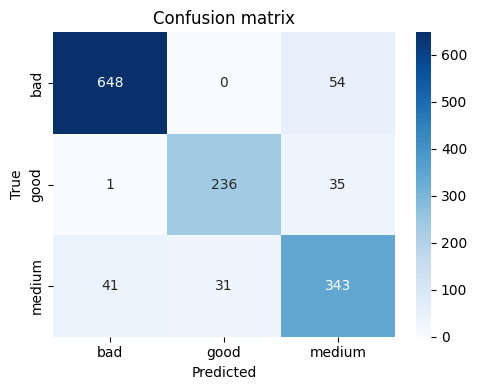

In [171]:
svc_clf = SVC(
    random_state=42,
    probability=True
)

svc_clf.fit(X_train_prep, y_train)

y_pred_svc = svc_clf.predict(X_test_prep)

evaluate_model("SVC", svc_clf, X_test_prep, y_test, normalize_cm=False)

#### Model hyperparameters

An SVC has several hyperparameters that control the shape and flexibility of the decision boundary.

Some of the most important ones are:

- `C`: controls the trade-off between maximizing the margin and correctly classifying the training points. Larger values allow the model to fit the training data more closely.
- `kernel`: specifies the type of decision boundary, for example `"linear"`, `"rbf"`, `"poly"`, or `"sigmoid"`.
- `gamma`: controls how far the influence of a single training example reaches in non-linear kernels such as `"rbf"`. Larger values produce more complex decision boundaries.
- `degree`: the degree of the polynomial kernel, used only when `kernel="poly"`.
- `probability`: whether to enable probability estimates. This can be useful for metrics such as ROC-AUC, but increases computation time.

In [159]:
def objective_svc(trial):
    kernel = trial.suggest_categorical("kernel", ["linear", "rbf", "poly", "sigmoid"])
    C = trial.suggest_float("C", 1e-2, 1e2, log=True)

    params = {
        "kernel": kernel,
        "C": C,
        "probability": True,
        "random_state": 42,
    }

    if kernel in ["rbf", "poly", "sigmoid"]:
        params["gamma"] = trial.suggest_float("gamma", 1e-4, 1e1, log=True)

    if kernel == "poly":
        params["degree"] = trial.suggest_int("degree", 2, 5)

    clf = SVC(**params)
    
    clf.fit(X_train_prep, y_train)

    y_val_pred = clf.predict(X_val_prep)

    return f1_score(y_val, y_val_pred, average="macro")

In [162]:
study_svc = optuna.create_study(direction="maximize")
study_svc.optimize(objective_svc, n_trials=30)

[I 2026-03-27 00:03:33,807] A new study created in memory with name: no-name-d90eb89b-1682-49a8-9cce-eeb396f6bf34
[I 2026-03-27 00:03:35,271] Trial 0 finished with value: 0.8491463649672605 and parameters: {'kernel': 'linear', 'C': 10.728581012690883}. Best is trial 0 with value: 0.8491463649672605.
[I 2026-03-27 00:03:37,224] Trial 1 finished with value: 0.8535194496270758 and parameters: {'kernel': 'rbf', 'C': 0.045187182247665963, 'gamma': 0.12870637305550267}. Best is trial 1 with value: 0.8535194496270758.
[I 2026-03-27 00:03:38,672] Trial 2 finished with value: 0.22371150470719645 and parameters: {'kernel': 'poly', 'C': 10.965922991480658, 'gamma': 0.0005743525487567246, 'degree': 5}. Best is trial 1 with value: 0.8535194496270758.
[I 2026-03-27 00:03:39,780] Trial 3 finished with value: 0.7012666790183167 and parameters: {'kernel': 'poly', 'C': 1.502821810555291, 'gamma': 0.07582703567199686, 'degree': 5}. Best is trial 1 with value: 0.8535194496270758.
[I 2026-03-27 00:03:41,15


Best SVC
Accuracy:  0.8934
Precision: 0.8801
Recall:    0.8899
Macro-F1:  0.8845
ROC-AUC (OvR): 0.9777


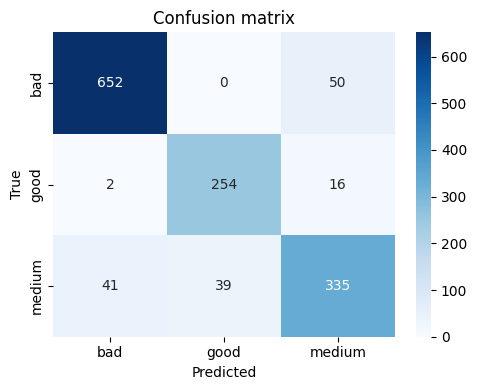

In [163]:
best_svc = SVC(
    **study_svc.best_params,
    probability=True,
    random_state=42
)

best_svc.fit(X_train_prep, y_train)

evaluate_model("Best SVC", best_svc, X_test_prep, y_test, normalize_cm=False)

### 5. Multi-Layer Perceptron

A **Multi-Layer Perceptron (MLP)** is one of the simplest types of neural network. Instead of building the prediction through a sequence of tree splits or by maximizing a margin, it learns a set of weights that transform the input features through several layers of non-linear operations.

This allows the model to capture more complex relationships between the features and the target classes. In other words, an MLP can learn patterns that are not easily described by a single straight boundary or a small set of simple rules.

In practice, MLP is a flexible model, but it also requires more care than tree-based methods. It does **not** handle missing values directly, and it is sensitive to the scale of the input features. This is why preprocessing is especially important: we need to impute missing values first and scale the continuous features before training the model.

Another important point is that neural networks usually have more moving parts. Their behaviour depends on choices such as the number of hidden layers, the number of neurons, the regularization strength, and the number of training iterations. Because of this, MLP can sometimes give strong results, but it can also be less stable and harder to tune than simpler models.

In this tutorial, we use MLP as a compact introduction to neural-network classification. The goal is not to go deeply into deep learning, but to compare a basic neural network with the other models we have already studied.


MLP
Accuracy:  0.8855
Precision: 0.8755
Recall:    0.8763
Macro-F1:  0.8759
ROC-AUC (OvR): 0.9767


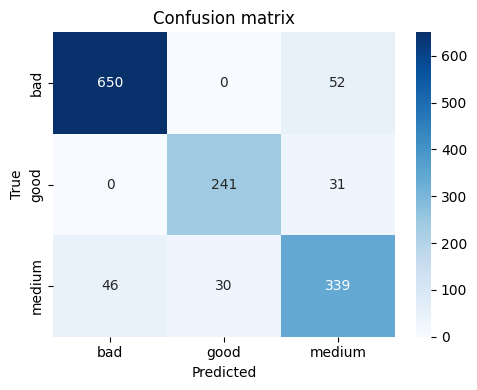

In [172]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42,
)

mlp.fit(X_train_prep, y_train)

evaluate_model("MLP", mlp, X_test_prep, y_test)

In [175]:
def objective_mlp(trial):
    hidden_layer_label = trial.suggest_categorical(
        "hidden_layer_sizes",
        ["32", "64", "64_32", "128_64"]
    )

    hidden_layer_map = {
        "32": (32,),
        "64": (64,),
        "64_32": (64, 32),
        "128_64": (128, 64),
    }

    hidden_layer_sizes = hidden_layer_map[hidden_layer_label]

    alpha = trial.suggest_float("alpha", 1e-5, 1e-1, log=True)
    learning_rate_init = trial.suggest_float("learning_rate_init", 1e-4, 1e-2, log=True)

    clf = MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        activation="relu",
        alpha=alpha,
        learning_rate_init=learning_rate_init,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42,
    )

    clf.fit(X_train_prep, y_train)
    y_val_pred = clf.predict(X_val_prep)

    return f1_score(y_val, y_val_pred, average="macro")

#### What are we tuning in the MLP?

In this example, we tune three important MLP hyperparameters.

- `hidden_layer_sizes`: the size and depth of the neural network
- `alpha`: the regularization strength
- `learning_rate_init`: the initial learning rate used during training

In [177]:
study_mlp = optuna.create_study(direction="maximize")
study_mlp.optimize(objective_mlp, n_trials=50)

[I 2026-03-27 00:24:14,066] A new study created in memory with name: no-name-32037225-0e33-4bb5-b96e-2b75330c41c7
[I 2026-03-27 00:24:14,303] Trial 0 finished with value: 0.8932261674757727 and parameters: {'hidden_layer_sizes': '64_32', 'alpha': 0.029423466732963522, 'learning_rate_init': 0.007438572111323069}. Best is trial 0 with value: 0.8932261674757727.
[I 2026-03-27 00:24:14,560] Trial 1 finished with value: 0.8729796861156865 and parameters: {'hidden_layer_sizes': '32', 'alpha': 0.00034367880303299317, 'learning_rate_init': 0.0013147392021928101}. Best is trial 0 with value: 0.8932261674757727.
[I 2026-03-27 00:24:15,478] Trial 2 finished with value: 0.8874946819307881 and parameters: {'hidden_layer_sizes': '128_64', 'alpha': 0.00026589519023453796, 'learning_rate_init': 0.0010462859987907}. Best is trial 0 with value: 0.8932261674757727.
[I 2026-03-27 00:24:15,862] Trial 3 finished with value: 0.8777090724871153 and parameters: {'hidden_layer_sizes': '32', 'alpha': 0.000249370

In [178]:
best_params = study_mlp.best_params.copy()

hidden_layer_map = {
    "32": (32,),
    "64": (64,),
    "64_32": (64, 32),
    "128_64": (128, 64),
}

best_params["hidden_layer_sizes"] = hidden_layer_map[best_params["hidden_layer_sizes"]]


Best MLP
Accuracy:  0.8877
Precision: 0.8799
Recall:    0.8818
Macro-F1:  0.8807
ROC-AUC (OvR): 0.9786


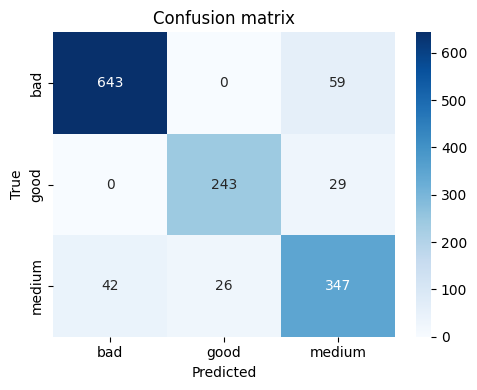

In [179]:
best_mlp = MLPClassifier(
    **best_params,
    activation="relu",
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42,
)

best_mlp.fit(X_train_prep, y_train)
evaluate_model("Best MLP", best_mlp, X_test_prep, y_test)

## 6) Comparing the results

In [183]:
models = {
    "Decision Tree": best_tree,
    "Random Forest": best_rf,
    "XGBoost": best_xgb,
    "SVC": best_svc,
    "MLP": best_mlp
}

def bootstrap_metric(y_true, y_pred, metric_func, n_boot=1000, random_state=42):
    rng = np.random.default_rng(random_state)
    n = len(y_true)
    scores = []

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)   # sample with replacement
        score = metric_func(y_true[idx], y_pred[idx])
        scores.append(score)

    return np.array(scores)

# Choose metric
metric_name = "Macro-F1"
metric_func = lambda yt, yp: f1_score(yt, yp, average="macro")

# Precompute predictions once
predictions = {}
for name, model in models.items():
    predictions[name] = model.predict(X_test_prep)

# Bootstrap distributions
bootstrap_results = []
for name, y_pred in predictions.items():
    scores = bootstrap_metric(
        y_true=y_test,
        y_pred=y_pred,
        metric_func=metric_func,
        n_boot=1000,
        random_state=42,
    )
    
    for s in scores:
        bootstrap_results.append({
            "Model": name,
            metric_name: s
        })

df_boot = pd.DataFrame(bootstrap_results)
df_boot.head()

,Model,Macro-F1
0,Decision Tree,0.871822
1,Decision Tree,0.861116
2,Decision Tree,0.862886
3,Decision Tree,0.864964
4,Decision Tree,0.856922


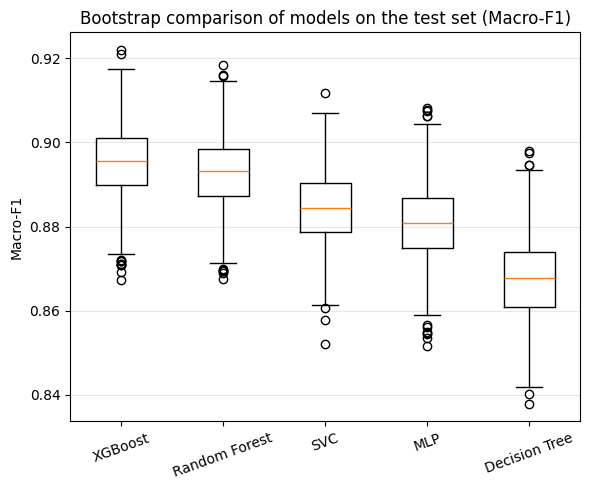

In [184]:
plt.figure(figsize=(6, 5))

order = (
    df_boot.groupby("Model")[metric_name]
    .median()
    .sort_values(ascending=False)
    .index
)

data_to_plot = [
    df_boot.loc[df_boot["Model"] == model_name, metric_name].values
    for model_name in order
]

plt.boxplot(data_to_plot, tick_labels=order)
plt.ylabel(metric_name)
plt.title(f"Bootstrap comparison of models on the test set ({metric_name})")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 7) Model interpretation

So far, we have focused on predictive performance. However, in many real applications we also want to understand **why** a model makes its predictions.

Model interpretation helps us answer questions such as:

- which features are most influential overall
- how individual features affect the predictions
- whether the model is relying on sensible patterns

The choice of interpretation method depends on the model.

For tree-based models such as Random Forest and XGBoost, a simple first step is to inspect **feature importance**. This gives a global view of which input variables contribute most to the model.

A more detailed approach is provided by **SHAP** values. SHAP helps explain individual predictions by showing how each feature pushes the prediction toward one class or another.

We will showcase both approaches on XGBoost example.

### Built-in feature importance

XGBoost provides built-in feature importance scores. These scores summarize how useful each feature was for constructing the boosted trees.

However, this type of importance has limitations:

- it does not show the direction of the effect
- it does not explain individual predictions
- importance values can depend on how the model splits correlated features

For this reason, built-in importance is best used as a first overview rather than as a complete explanation.

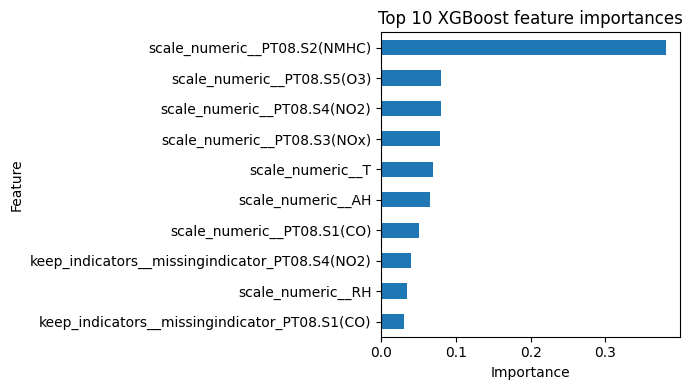

In [202]:
feature_names = feature_cols.copy()

xgb_importance = pd.Series(
    best_xgb.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
xgb_importance.head(10).sort_values().plot(kind="barh")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 XGBoost feature importances")
plt.tight_layout()
plt.show()


In [193]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


### SHAP summary plot

SHAP values provide a more detailed interpretation of the model.

For a chosen class, the SHAP value of a feature tells us how much that feature pushes the prediction toward or away from that class.

In the summary plot:

- features are ordered by overall importance
- each point represents one object
- the horizontal position shows whether the feature increased or decreased the score for the chosen class
- the colour indicates whether the feature value was low or high

This gives much more information than a simple importance ranking, because it shows both **which features matter** and **how they affect the model output**.

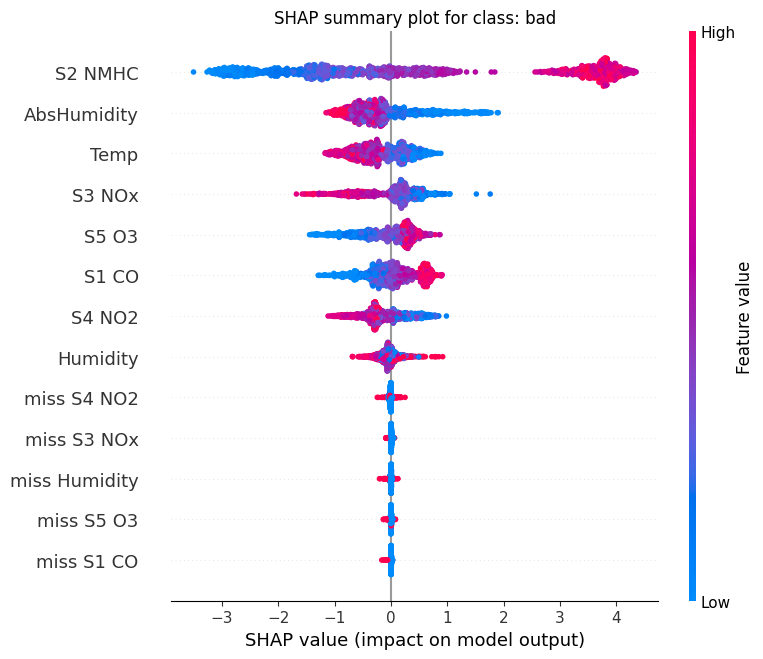

In [200]:
pretty_names = {
    "PT08.S1(CO)": "S1 CO",
    "PT08.S2(NMHC)": "S2 NMHC",
    "PT08.S3(NOx)": "S3 NOx",
    "PT08.S4(NO2)": "S4 NO2",
    "PT08.S5(O3)": "S5 O3",
    "T": "Temp",
    "RH": "Humidity",
    "AH": "AbsHumidity",
}

pretty_feature_names = [pretty_names.get(name, name) for name in feature_cols]

X_test_prep_df = pd.DataFrame(
    X_test_prep,
    columns=pretty_feature_names,
    index=X_test.index
)

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test_prep_df)

target_name = "bad"
target_id = le.transform([target_name])[0]

if isinstance(shap_values, list):
    sv = shap_values[target_id]
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    sv = shap_values[:, :, target_id]
else:
    sv = shap_values

shap.summary_plot(sv, X_test_prep_df, show=False)
plt.title(f"SHAP summary plot for class: {target_name}")
plt.tight_layout()
plt.show()

The SHAP summary plot shows that `S2 NMHC` is the most influential feature for predicting the `bad` air-quality class. High values of this feature strongly increase the model output for `bad`, while low values push the prediction in the opposite direction.

Other important features include `AbsHumidity`, `Temp`, and `S3 NOx`. For these variables, the plot suggests that lower values tend to increase the probability of the `bad` class, while higher values tend to decrease it.

This kind of plot is useful because it goes beyond a simple ranking of features: it also shows the **direction** of the effect and the spread of contributions across individual objects.


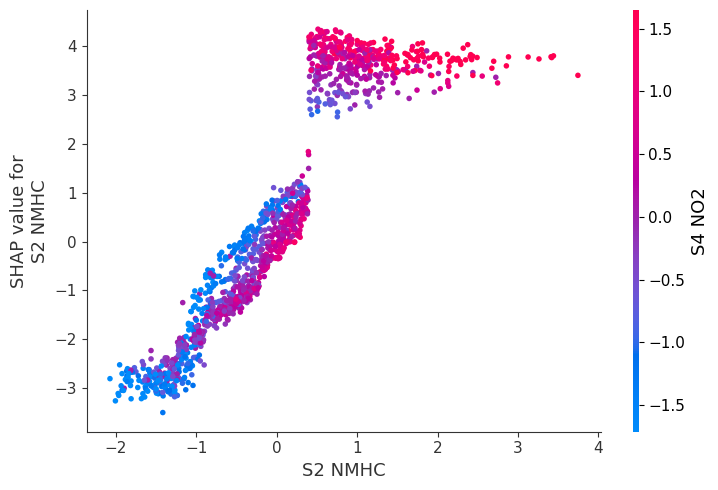

In [201]:
shap.dependence_plot(
    "S2 NMHC",
    sv,
    X_test_prep_df,
    show=False
)
plt.tight_layout()
plt.show()

The SHAP dependence plot shows that `S2 NMHC` has a strong and non-linear effect on the prediction of the `bad` class.

Low values of `S2 NMHC` produce strongly negative SHAP values, which means they push the model away from the `bad` class. As `S2 NMHC` increases, its contribution rises rapidly and then reaches a high positive plateau, meaning that large values strongly support the `bad` prediction.

The colour represents `S4 NO2`, which suggests a possible interaction between the two features. For similar values of `S2 NMHC`, higher `S4 NO2` often corresponds to slightly larger SHAP values. This indicates that the effect of `S2 NMHC` may become stronger when `S4 NO2` is also high.

# Regression

## Regression example

This dataset is not limited to classification. It can also be used for **regression**, because the reference pollutant measurements are numerical variables.

In a regression task, the goal is to predict a **continuous value** rather than assign each observation to a class. Here, instead of predicting categories such as `good`, `medium`, or `bad`, we try to estimate the actual concentration of one pollutant.

For example, we can choose:

- `NO2(GT)`

as the regression target.

The input features remain the measurements provided by the sensor system and the environmental conditions:

- `PT08.S1(CO)`
- `PT08.S2(NMHC)`
- `PT08.S3(NOx)`
- `PT08.S4(NO2)`
- `PT08.S5(O3)`
- `T`
- `RH`
- `AH`

We can also include information derived from `Date` and `Time`, since air quality often changes with daily and seasonal cycles. Useful time-related predictors include:

- hour of day
- day of week
- month
- weekend indicator

This gives a supervised regression problem in which the model learns to estimate the true pollutant concentration from sensor responses, environmental variables, and optional time information.

The main difference from the previous classification setup is the form of the target:

- in **classification**, the target is a category
- in **regression**, the target is a numerical value

Because of this, we also need different evaluation metrics. Instead of accuracy or F1 score, we use metrics that measure how close the predicted values are to the true concentrations.

In [207]:
df = df.copy()

df["datetime"] = pd.to_datetime(
    df["Date"].astype(str) + " " + df["Time"].astype(str),
    format="%d/%m/%Y %H.%M.%S",
    errors="coerce"
)

df["hour"] = df["datetime"].dt.hour
df["day_of_week"] = df["datetime"].dt.dayofweek
df["month"] = df["datetime"].dt.month
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

In [208]:
feature_cols = [
    "PT08.S1(CO)",
    "PT08.S2(NMHC)",
    "PT08.S3(NOx)",
    "PT08.S4(NO2)",
    "PT08.S5(O3)",
    "T",
    "RH",
    "AH",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
]

### Time-based train/validation/test split

For this regression example, we use a **time-based split** instead of a random split.

This choice is more appropriate because air-quality measurements are collected over time, and both the pollutant concentration and the sensor behaviour may vary across the year.

We therefore sort the dataset by time and split it into three consecutive blocks:

- the earliest 60% of observations for training
- the next 20% for validation
- the final 20% for testing

This makes the evaluation more realistic, because the model is trained on past data and tested on later observations.

In [227]:
target_col = "NO2(GT)"

# Keep only rows where the regression target is available
df_reg = df.copy()
df_reg[target_col] = df_reg[target_col].replace(-200, np.nan)
df_reg = df_reg[df_reg[target_col].notna()].copy()

# Make sure rows are ordered in time
df_reg = df_reg.sort_values("datetime").copy()

X_reg = df_reg[feature_cols]
y_reg = df_reg[target_col]

n = len(df_reg)
n_train = int(0.6 * n)
n_val = int(0.2 * n)

X_train_reg = X_reg.iloc[:n_train]
y_train_reg = y_reg.iloc[:n_train]

X_val_reg = X_reg.iloc[n_train:n_train + n_val]
y_val_reg = y_reg.iloc[n_train:n_train + n_val]

X_test_reg = X_reg.iloc[n_train + n_val:]
y_test_reg = y_reg.iloc[n_train + n_val:]

print("Train shape:", X_train_reg.shape)
print("Val shape:", X_val_reg.shape)
print("Test shape:", X_test_reg.shape)

Train shape: (4164, 12)
Val shape: (1388, 12)
Test shape: (1389, 12)


In [228]:
t_train_reg = df_reg["datetime"].iloc[:n_train]
t_val_reg = df_reg["datetime"].iloc[n_train:n_train + n_val]
t_test_reg = df_reg["datetime"].iloc[n_train + n_val:]

## 1) Regression metrics

For regression, common choices include:

### Mean Absolute Error (MAE)

$$
\mathrm{MAE} = \frac{1}{n}\sum_{i=1}^{n} \left| y_i - \hat{y}_i \right|
$$

where:

- \(y_i\) is the true value
- \($\hat{y}_i$\) is the predicted value
- \(n\) is the number of samples

MAE measures the average absolute difference between the predictions and the true values. It is easy to interpret because it has the same units as the target variable.

### Root Mean Squared Error (RMSE)

$$
\mathrm{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)^2}
$$

RMSE is similar to MAE, but it penalizes large errors more strongly because the errors are squared before averaging. This makes it more sensitive to occasional large mistakes.

### Coefficient of Determination ($R^2$)

$$
R^2 = 1 - \frac{\sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)^2}{\sum_{i=1}^{n} \left( y_i - \bar{y} \right)^2}
$$

where \(\bar{y}\) is the mean of the true target values.

The numerator measures the residual error of the model, while the denominator measures the total variation of the target around its mean.

- \(R^2 = 1\) means perfect predictions
- \(R^2 \approx 0\) means the model is not much better than predicting the mean target value
- \(R^2 < 0\) means the model is worse than that baseline

### How to interpret them together

- **MAE** tells us the typical size of the prediction error
- **RMSE** tells us whether the model makes some large mistakes
- **\(R^2\)** tells us how much of the target variation is explained by the model

Looking at all three together gives a more complete picture of regression performance.

## 2) XGBoost prediction

In [229]:
xgb_reg = XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

xgb_reg.fit(X_train_reg, y_train_reg)

y_pred_reg = xgb_reg.predict(X_test_reg)

print("MAE:", mean_absolute_error(y_test_reg, y_pred_reg))
print("RMSE:", root_mean_squared_error(y_test_reg, y_pred_reg))
print("R^2:", r2_score(y_test_reg, y_pred_reg))

MAE: 39.86368976040999
RMSE: 46.94509789107562
R^2: 0.17123368550487672


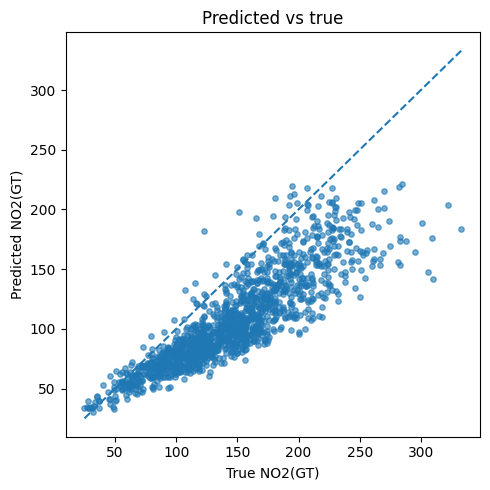

In [274]:
plt.figure(figsize=(5,5))

sc = plt.scatter(
    y_test_reg,
    y_pred_reg,
    s=15,
    alpha=0.6
)

plt.plot(
    [y_test_reg.min(), y_test_reg.max()],
    [y_test_reg.min(), y_test_reg.max()],
    linestyle="--"
)

plt.xlabel("True NO2(GT)")
plt.ylabel("Predicted NO2(GT)")
plt.title("Predicted vs true")
plt.tight_layout()
plt.show()

The predicted-versus-true plot shows a clear correlation between the predictions and the true `NO2(GT)` values, so the model is learning an important part of the signal. However, the points are not tightly concentrated around the diagonal, which means that the predictions are only approximate and the errors are still substantial.

The scatter becomes wider at higher `NO2(GT)` values, indicating that the model is less precise in the high-pollution regime. In addition, many of the largest true values are predicted below the diagonal, which suggests a tendency to underestimate extreme pollution events.

Overall, the model captures the general trend, but it does not reproduce the target accurately enough for the predicted-versus-true relation to follow the one-to-one line closely.

## 3) Quantile regression

A standard regression model predicts a single value, usually an estimate of the conditional mean.

In some cases, we want more information than one central prediction. For example, we may want to know a plausible lower and upper range for the target.

Quantile regression addresses this by predicting different quantiles of the target distribution. For example:

- a lower quantile, such as 0.16
- the median, 0.5
- an upper quantile, such as 0.84

Together, these predictions provide a simple uncertainty band around the central estimate.

This is especially useful for time-dependent data, where we may want to visualize not only the expected trend, but also the spread of possible values over time.

In [237]:
xgb_q = XGBRegressor(
    objective="reg:quantileerror",
    quantile_alpha=np.array([0.16, 0.5, 0.84]),
    tree_method="hist",
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

xgb_q.fit(X_train_reg, y_train_reg)

pred_q = xgb_q.predict(X_test_reg)   # shape: (n_samples, 3)
q16 = pred_q[:, 0]
q50 = pred_q[:, 1]
q84 = pred_q[:, 2]

In [241]:
t_test_reg = df_reg.loc[X_test_reg.index, "datetime"]

plot_df = pd.DataFrame({
    "time": t_test_reg,
    "y_true": y_test_reg,
    "q16": q16,
    "q50": q50,
    "q84": q84,
}).sort_values("time")

plot_df = plot_df.set_index("time")

In [242]:
test_start = t_test_reg.min()
test_end = t_test_reg.max()

print(test_start, test_end)

2005-01-30 15:00:00 2005-04-04 14:00:00


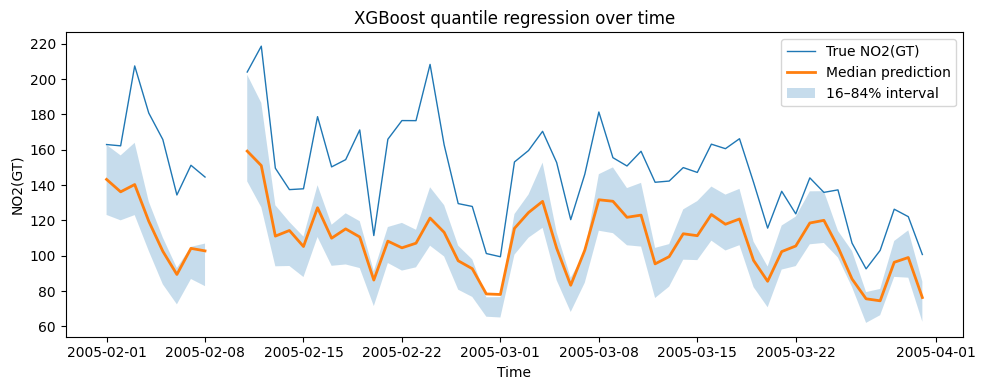

In [243]:
plot_daily = plot_df.resample("D").mean()

plot_short = plot_daily.loc["2005-02":"2005-03"].copy()

plt.figure(figsize=(10, 4))
plt.plot(plot_short.index, plot_short["y_true"], label="True NO2(GT)", linewidth=1)
plt.plot(plot_short.index, plot_short["q50"], label="Median prediction", linewidth=2)
plt.fill_between(
    plot_short.index,
    plot_short["q16"],
    plot_short["q84"],
    alpha=0.25,
    label="16–84% interval"
)

plt.xlabel("Time")
plt.ylabel("NO2(GT)")
plt.title("XGBoost quantile regression over time")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print("Train mean:", y_train_reg.mean(), " median:", y_train_reg.median())
print("Val   mean:", y_val_reg.mean(),   " median:", y_val_reg.median())
print("Test  mean:", y_test_reg.mean(),  " median:", y_test_reg.median())

Train mean: 97.23198847262248  median: 95.0
Val   mean: 131.9293948126801  median: 128.0
Test  mean: 145.72210223182145  median: 144.0


The strong underestimation on the test set can be explained by a clear shift in the target distribution over time.

In particular, the average and median `NO2(GT)` values increase substantially from the training period to the validation period and then again to the test period:

- train mean: 97.2, median: 95
- validation mean: 131.9, median: 128
- test mean: 145.7, median: 144

This means that the model is trained mostly on an earlier, lower-pollution regime and then evaluated on a later, higher-pollution regime. As a result, the model tends to predict values that are systematically too low on the test set.

This is a common issue in time-dependent data: even when a model performs reasonably on validation, its performance may degrade on a later test period if the data distribution changes over time.

In [264]:
def objective_xgb_q50(trial):
    model = XGBRegressor(
        objective="reg:quantileerror",
        quantile_alpha=0.5,
        tree_method="hist",
        n_estimators=trial.suggest_int("n_estimators", 200, 800),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        learning_rate=trial.suggest_float("learning_rate", 5e-3, 0.1, log=True),
        subsample=trial.suggest_float("subsample", 0.7, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.7, 1.0),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 10),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-6, 1.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-6, 5.0, log=True),
        random_state=42,
        n_jobs=-1,
    )

    model.fit(X_train_reg, y_train_reg)
    pred = model.predict(X_val_reg)
    return mean_pinball_loss(y_val_reg, pred, alpha=0.5)

In [265]:
study_xgb_q50 = optuna.create_study(direction="minimize")
study_xgb_q50.optimize(objective_xgb_q50, n_trials=50)

print("Best params:")
print(study_xgb_q50.best_params)

[I 2026-03-27 01:55:09,364] A new study created in memory with name: no-name-c4adc689-c0e1-463d-9d14-2f9ba95806fc
[I 2026-03-27 01:55:11,002] Trial 0 finished with value: 10.570400667465385 and parameters: {'n_estimators': 710, 'max_depth': 10, 'learning_rate': 0.029146648471007484, 'subsample': 0.7710813968047756, 'colsample_bytree': 0.778314787186752, 'min_child_weight': 10, 'reg_alpha': 2.9063608539117375e-05, 'reg_lambda': 1.0771862552359592e-05}. Best is trial 0 with value: 10.570400667465385.
[I 2026-03-27 01:55:11,612] Trial 1 finished with value: 14.524852826890752 and parameters: {'n_estimators': 204, 'max_depth': 10, 'learning_rate': 0.0057304878251174425, 'subsample': 0.9000485333030283, 'colsample_bytree': 0.9247124779770257, 'min_child_weight': 8, 'reg_alpha': 4.589840722192871e-06, 'reg_lambda': 1.3811842723386685e-05}. Best is trial 0 with value: 10.570400667465385.
[I 2026-03-27 01:55:11,937] Trial 2 finished with value: 10.582988627705863 and parameters: {'n_estimators

Best params:
{'n_estimators': 289, 'max_depth': 9, 'learning_rate': 0.02309449789459905, 'subsample': 0.806991435000582, 'colsample_bytree': 0.741971316810607, 'min_child_weight': 4, 'reg_alpha': 1.745693235457012e-05, 'reg_lambda': 0.002995665237850586}


In [266]:
best_params = study_xgb_q50.best_params

xgb_q16 = XGBRegressor(
    **best_params,
    objective="reg:quantileerror",
    quantile_alpha=0.16,
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
)

xgb_q50 = XGBRegressor(
    **best_params,
    objective="reg:quantileerror",
    quantile_alpha=0.5,
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
)

xgb_q84 = XGBRegressor(
    **best_params,
    objective="reg:quantileerror",
    quantile_alpha=0.84,
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
)

X_trainval_reg = pd.concat([X_train_reg, X_val_reg], axis=0)
y_trainval_reg = pd.concat([y_train_reg, y_val_reg], axis=0)

for model in [xgb_q16, xgb_q50, xgb_q84]:
    model.fit(X_trainval_reg, y_trainval_reg)

q16 = xgb_q16.predict(X_test_reg)
q50 = xgb_q50.predict(X_test_reg)
q84 = xgb_q84.predict(X_test_reg)

In [267]:
t_test_reg = df_reg.loc[X_test_reg.index, "datetime"]

plot_df = pd.DataFrame({
    "time": t_test_reg,
    "y_true": y_test_reg,
    "q16": q16,
    "q50": q50,
    "q84": q84,
}).sort_values("time")

plot_df = plot_df.set_index("time")

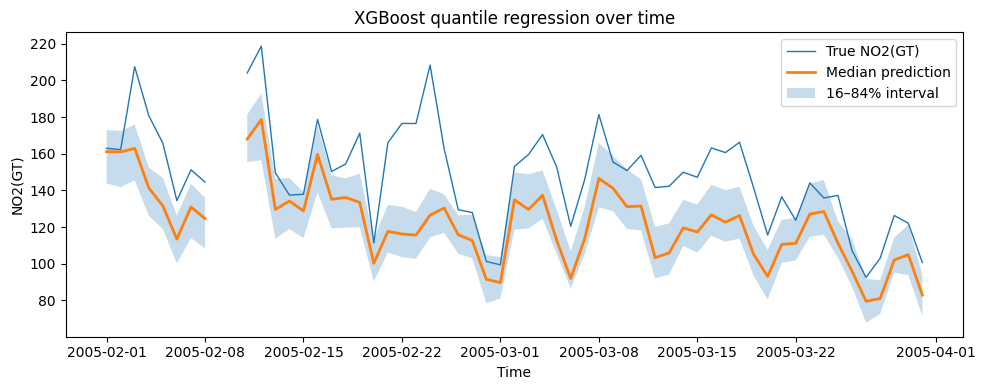

In [268]:
plot_daily = plot_df.resample("D").mean()

plot_short = plot_daily.loc["2005-02":"2005-03"].copy()

plt.figure(figsize=(10, 4))
plt.plot(plot_short.index, plot_short["y_true"], label="True NO2(GT)", linewidth=1)
plt.plot(plot_short.index, plot_short["q50"], label="Median prediction", linewidth=2)
plt.fill_between(
    plot_short.index,
    plot_short["q16"],
    plot_short["q84"],
    alpha=0.25,
    label="16–84% interval"
)

plt.xlabel("Time")
plt.ylabel("NO2(GT)")
plt.title("XGBoost quantile regression over time")
plt.legend()
plt.tight_layout()
plt.show()

Retraining the quantile models on the combined training and validation data improves the result noticeably. The median prediction is now closer to the true `NO2(GT)` series, and the systematic underestimation seen before is reduced.

The model still produces a smoother curve than the observations, which means that the sharpest short-term peaks remain difficult to reproduce. Some of the highest values still lie above the predicted interval, showing that extreme pollution events are harder to capture than the general trend.

Overall, the updated model gives a better description of the time-dependent behaviour of `NO2(GT)`, while also illustrating an important practical point: when the validation period is closer in distribution to the test period, retraining on both training and validation data can improve final performance.